# Unsupervised Learning with Hierarchical Clustering
### What will we learn?
* The intuition behind hierarchical (agglomerative) clustering and the Ward linkage.
* How to read a dendrogram and decide on an appropriate number of clusters.
* Practical data-preprocessing steps (selecting numeric columns, scaling).
* Dimensionality reduction with PCA for 2-D exploratory plots.
* Communicating cluster insights on a world map.

We use the **Democracy & Dictatorship** dataset from TidyTuesday, filtered to year 2020. Each row is a country with political indicators.

### Part 1: Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Democracy & Dictatorship dataset from TidyTuesday
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-11-05/democracy_data.csv"
df_full = pd.read_csv(url)

# Filter to year 2020
data = df_full[df_full["year"] == 2020].copy()
print(f"Countries in 2020: {len(data)}")
data.head()

Countries in 2020: 208


,country_name,country_code,year,regime_category_index,regime_category,is_monarchy,is_commonwealth,monarch_name,monarch_accession_year,monarch_birthyear,...,electoral_category_index,electoral_category,spatial_electoral,has_alternation,is_multiparty,has_free_and_fair_election,parliamentary_election_year,election_month,election_year,has_postponed_election
70,Afghanistan,AFG,2020,3.0,Civilian dictatorship,False,False,NaN,NaN,NaN,...,2.0,non-democratic multi-party elections,2.00,False,True,False,0.0,NaN,NaN,False
141,Albania,ALB,2020,0.0,Parliamentary democracy,False,False,NaN,NaN,NaN,...,3.0,democratic elections,2.80,True,True,True,0.0,NaN,NaN,False
212,Algeria,DZA,2020,3.0,Civilian dictatorship,False,False,NaN,NaN,NaN,...,2.0,non-democratic multi-party elections,2.50,False,True,False,0.0,NaN,NaN,False
283,Angola,AGO,2020,3.0,Civilian dictatorship,False,False,NaN,NaN,NaN,...,2.0,non-democratic multi-party elections,2.25,False,True,True,0.0,NaN,NaN,False
354,Anguilla,AIA,2020,NaN,British Overseas Territory,True,False,Elizabeth II,1952.0,1926.0,...,3.0,democratic elections,3.00,True,True,True,1.0,April,2020.0,False


### Part 2: Feature Selection

Numeric feature columns (17): ['regime_category_index', 'spatial_democracy', 'parliament_chambers', 'lower_house_members', 'spatial_electoral', 'electoral_category_index', 'is_monarchy', 'is_democracy', 'is_presidential', 'is_colony', 'is_communist', 'has_proportional_voting', 'has_full_suffrage', 'is_multiparty', 'has_free_and_fair_election', 'has_alternation', 'has_new_constitution']
Countries with complete data: 184


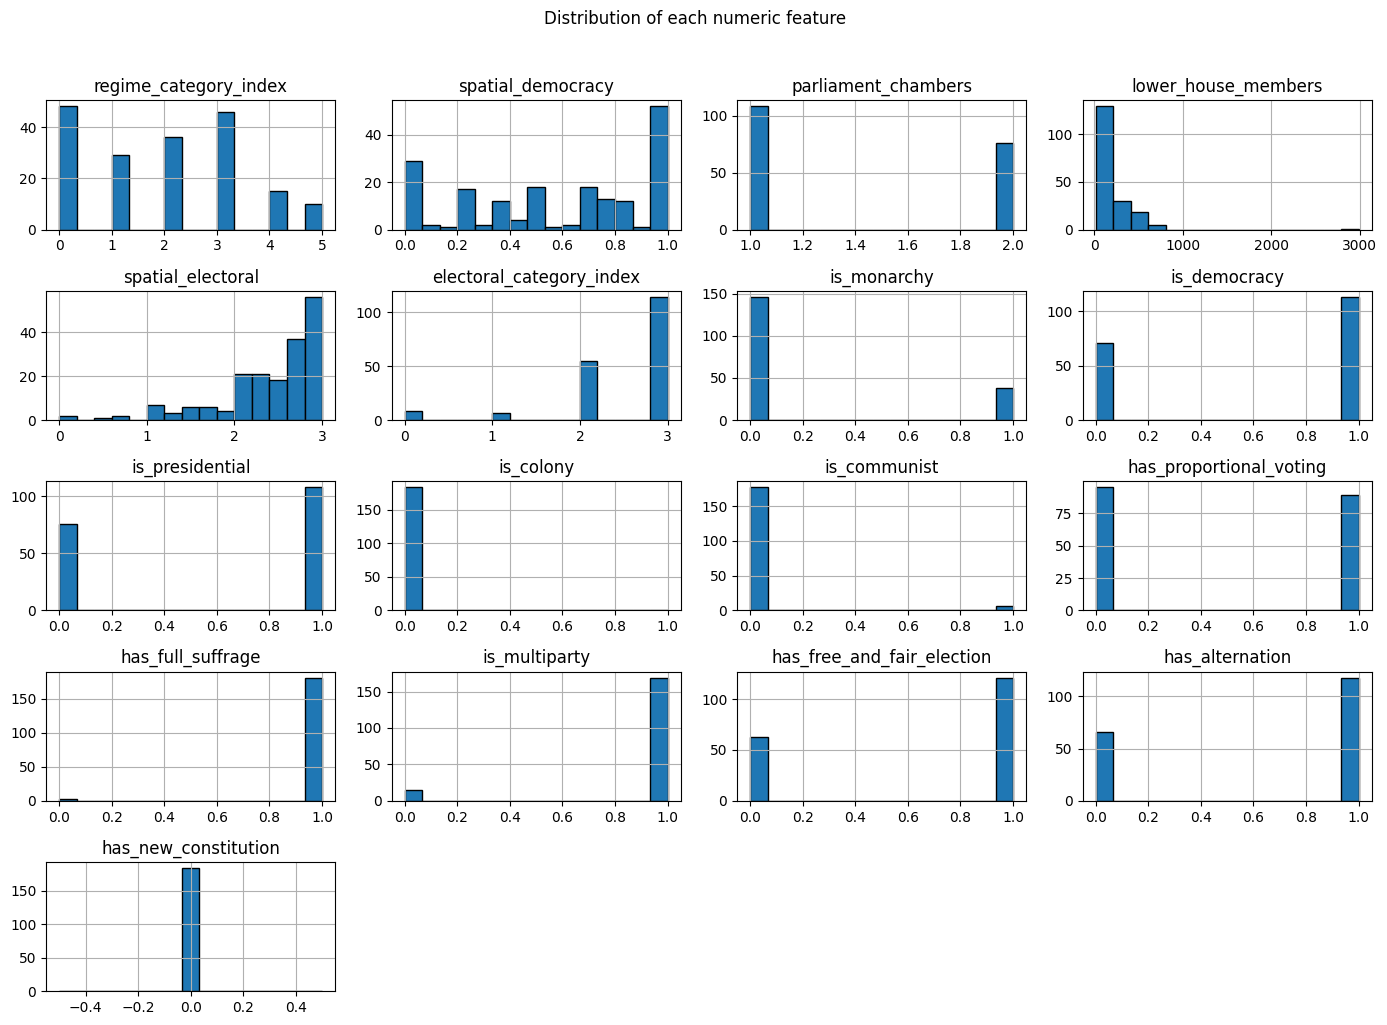

In [2]:
# The dataset has boolean columns stored as object type (True/False strings).
# We need to explicitly select and convert them to numeric.

# Boolean feature columns to convert
bool_cols = ["is_monarchy", "is_democracy", "is_presidential", "is_colony", "is_communist",
             "has_proportional_voting", "has_full_suffrage", "is_multiparty",
             "has_free_and_fair_election", "has_alternation", "has_new_constitution"]

# Numeric feature columns (drop those with mostly NaN)
num_cols = ["regime_category_index", "spatial_democracy", "parliament_chambers",
            "lower_house_members", "spatial_electoral", "electoral_category_index"]

# Convert boolean columns to int (True=1, False=0, NaN stays NaN)
for col in bool_cols:
    data[col] = data[col].map({True: 1, False: 0})

feature_cols = num_cols + bool_cols

features_df = data[feature_cols].copy()

# Drop rows with NaN
mask = features_df.notna().all(axis=1)
features_df = features_df[mask]
country_names = data.loc[mask, "country_name"].values
country_codes = data.loc[mask, "country_code"].values

print(f"Numeric feature columns ({len(feature_cols)}):", list(feature_cols))
print(f"Countries with complete data: {len(features_df)}")

# Optional sanity-check visual
features_df.hist(figsize=(14, 10), edgecolor="k", bins=15)
plt.suptitle("Distribution of each numeric feature", y=1.02)
plt.tight_layout()
plt.show()

### Part 3: Standardize by Scaling
- Hierarchical clustering uses Euclidean distance; indicators measured on different scales would dominate the metric.
- We standardize to zero mean / unit variance using `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

### Part 4: Building the Hierarchical Tree
* **Ward linkage** merges clusters that yield the *smallest* increase in total within-cluster variance.
* The dendrogram gives us two insights:
  1. Similarity structure (who merges early).
  2. Reasonable cut heights (horizontal line) for k clusters.
We show country name labels on the dendrogram.

In [ ]:
# Import clustering classes from scipy


# Compute the linkage matrix


# Plot dendrogram
plt.figure(figsize=(20, 7))

dendrogram()

plt.title("Hierarchical Clustering Dendrogram (Countries)")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.xticks(rotation=90, fontsize=6)
plt.show()

### Part 5: Choosing k & Assigning Clusters
After visually inspecting the dendrogram we select **k=4** (feel free to experiment).
Agglomerative clustering with the same linkage method produces integer labels we can append to the dataframe.

In [ ]:
# Import AgglomerativeClustering from sklearn


# Select k and assign cluster labels
k =
agg =
cluster_labels =

# Create a results dataframe
results = pd.DataFrame({
    "country": country_names,
    "country_code": country_codes,
    "Cluster": cluster_labels
})

print(results.head())
print("\nCluster sizes:")
print(results["Cluster"].value_counts())

### Part 6: Low-Dimensional Insight with PCA
**Note:** PCA is *only* for display; it was **not** used to fit the clusters.

In [ ]:
from sklearn.decomposition import PCA

# Reduce the dimensions for visualization (2D scatter plot)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
# Place cluster lables in PCA
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=60, edgecolor='k', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering on Democracy Data (via PCA)')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

### Part 7: Putting Clusters on the Map
Choropleth maps make the result tangible for non-technical audiences.
Plotly Express offers an immediate interactive world map keyed by **country code** (ISO alpha-3).

In [ ]:
import plotly.express as px

# Define a discrete color mapping for the clusters
color_map = {0: "blue", 1: "orange", 2: "green", 3: "red"}

# Create the choropleth map using country_code (ISO alpha-3)
fig = px.choropleth(
    results,
    locations='country_code',
    locationmode='ISO-3',
    title='Country Clusters on World Map (Democracy & Dictatorship Features)',
    color='Cluster',
    color_discrete_map=color_map,
    hover_name='country'
)

fig.update_geos(fitbounds="locations", visible=True)
fig.update_layout(
    legend_title_text='Cluster',
    legend_title_side='top'
)

fig.show()

### Part 8: Silhouette Score Optimization

In [ ]:
# Import silhouette_score
from sklearn.metrics import silhouette_score

# Range of candidate cluster counts
k_range = range(2, 11)
sil_scores = []

# Loop through and save each AgglomerativeClustering for different values of k


# Plot the curve
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Analysis for Agglomerative (Ward) Clustering")
plt.grid(True, alpha=0.3)
plt.show()

# Print best k
best_k = list(k_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k}  (score={max(sil_scores):.3f})")